## Installing dependencies

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

C:\Users\yan1k\PycharmProjects\heart_disease_kaggle\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_DIR = Path('datasets')
TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
TARGET = 'Heart Disease'

train_df = pd.read_csv(TRAIN_PATH, index_col="id")
train_df[TARGET] = train_df[TARGET].replace({'Presence': 1, 'Absence': 0})
test_df = pd.read_csv(TEST_PATH, index_col="id")

feature_columns = [c for c in train_df.columns if c not in [TARGET, 'id']]
continuous_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
categorical_features = [column for column in feature_columns if column not in continuous_features]

print(f'Train: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns')
print(f'Test:  {test_df.shape[0]:,} rows x {test_df.shape[1]} columns')
train_df.head()


Train: 630,000 rows x 14 columns
Test:  270,000 rows x 13 columns


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
id,,,,,,,,,,,,,,
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


## Data audit

In [14]:
print('Train data:')
train_df.info()
print('\nTest data:')
test_df.info()

Train data:
<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hea

In [36]:
for df in (train_df, test_df):
    df[continuous_features] = df[continuous_features].replace([np.inf, -np.inf], np.nan)

train_df = train_df.drop_duplicates(subset=feature_columns)
test_df = test_df.drop_duplicates(subset=feature_columns)

print(f"Missing values (train): {train_df.isna().sum().sum():,}")
print(f"Missing values (test):  {test_df.isna().sum().sum():,}")

Missing values (train): 0
Missing values (test):  0


In [18]:
target_counts = train_df[TARGET].value_counts().sort_index()
target_shares = target_counts / len(train_df) * 100

for label in target_counts.index:
    print(f'{label}: {target_counts[label]:,} rows ({target_shares[label]:.2f}%)')

Absence: 347,546 rows (55.17%)
Presence: 282,454 rows (44.83%)


## EDA

Continuous features: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
Categorical features: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


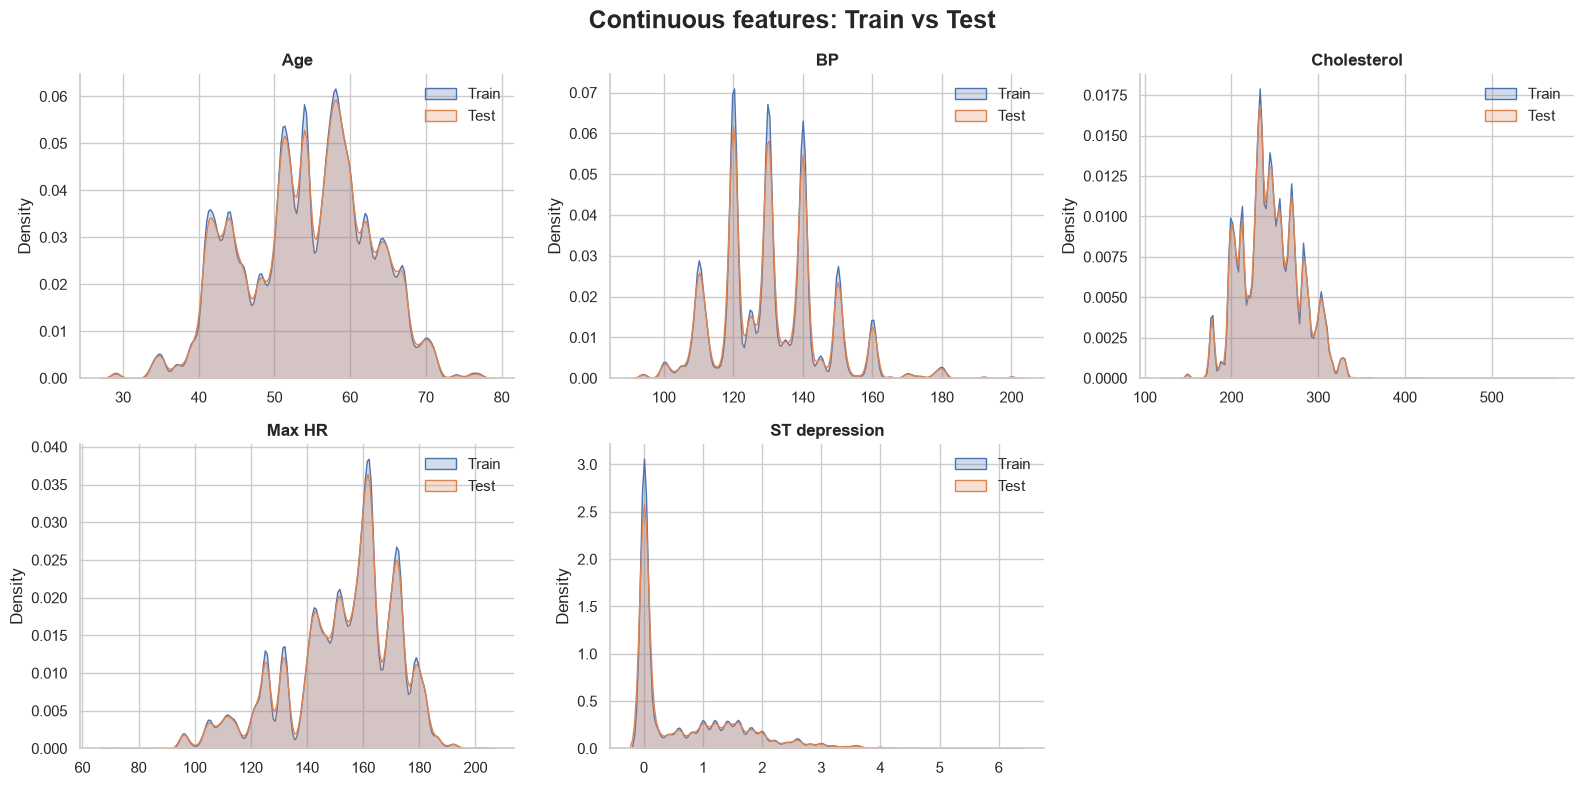

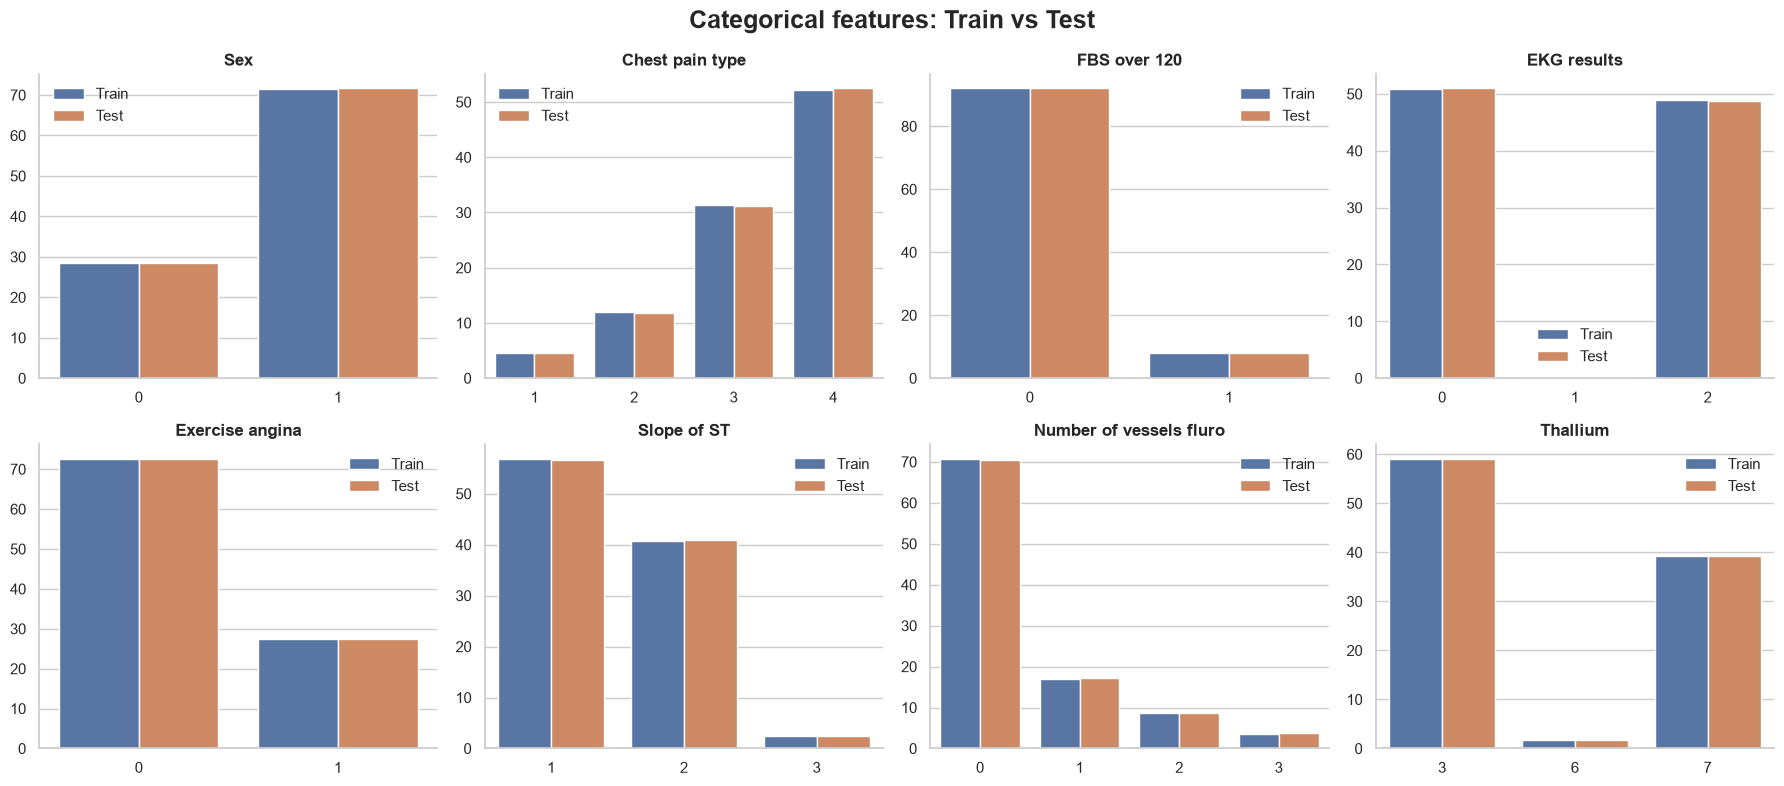

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, col in zip(axes, continuous_features):
    sns.kdeplot(train_df[col], ax=ax, label='Train', fill=True, alpha=0.25)
    sns.kdeplot(test_df[col], ax=ax, label='Test', fill=True, alpha=0.25)

    ax.set_title(col, weight='bold')
    ax.set_xlabel('')
    ax.legend(frameon=False)

for ax in axes[len(continuous_features):]:
    ax.remove()

fig.suptitle('Continuous features: Train vs Test', fontsize=18, weight='bold')
sns.despine()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for ax, col in zip(axes, categorical_features):
    plot_df = pd.concat({
        'Train': train_df[col].value_counts(normalize=True).mul(100),
        'Test': test_df[col].value_counts(normalize=True).mul(100)
    }, axis=1).fillna(0)

    plot_df = plot_df.reset_index(names=col)
    plot_df = plot_df.melt(id_vars=col, var_name='Dataset', value_name='Share (%)')

    sns.barplot(data=plot_df, x=col, y='Share (%)', hue='Dataset', ax=ax)

    ax.set_title(col, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend(frameon=False)

for ax in axes[len(categorical_features):]:
    ax.remove()

fig.suptitle('Categorical features: Train vs Test', fontsize=18, weight='bold')
sns.despine()
plt.tight_layout()
plt.show()

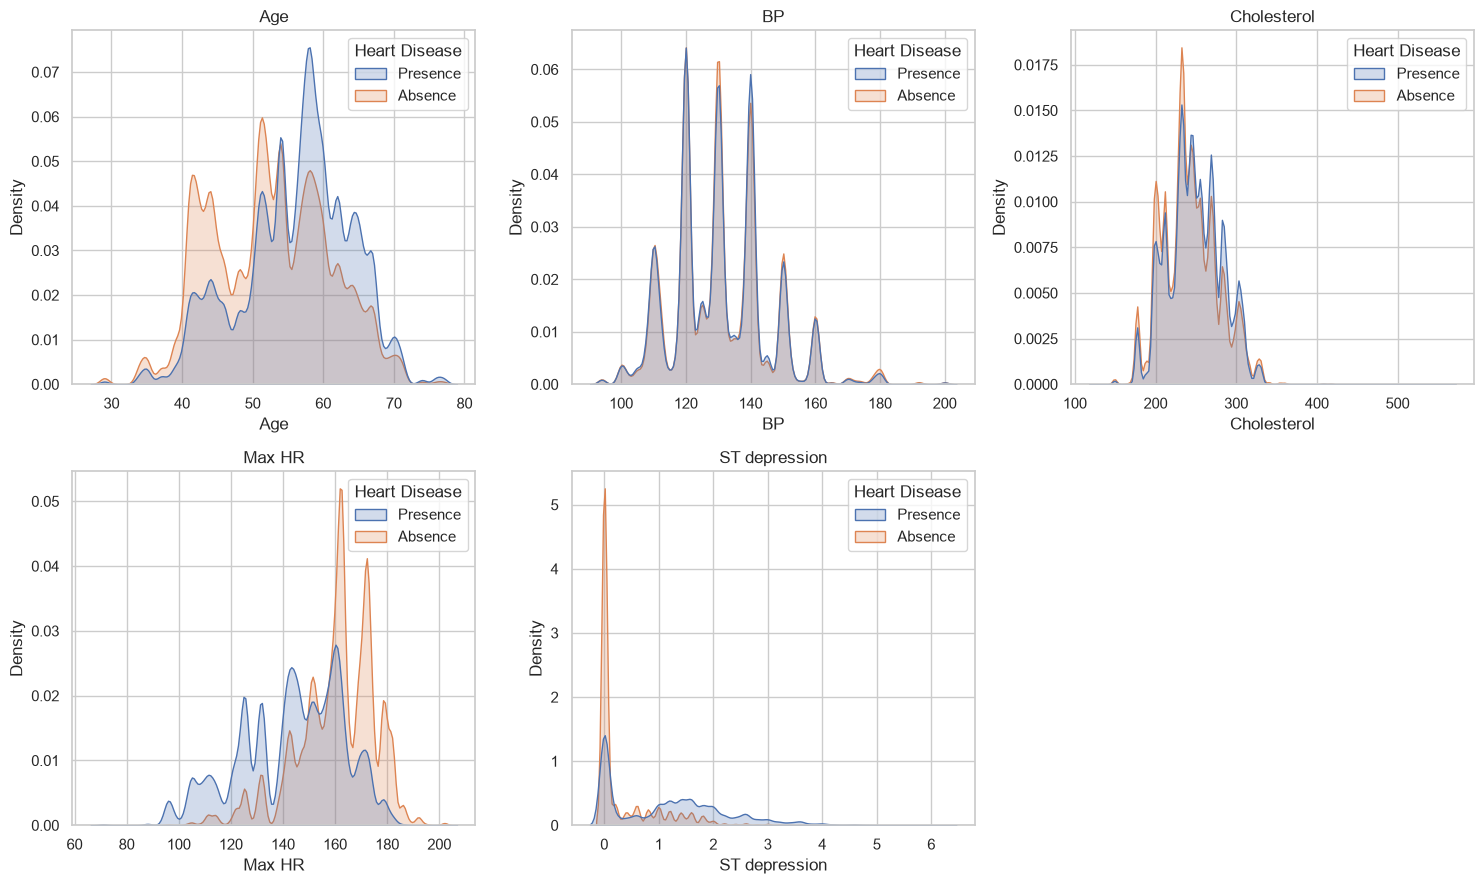

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, col in zip(axes, continuous_features):
    sns.kdeplot(
        data=train_df,
        x=col,
        hue=TARGET,
        fill=True,
        common_norm=False,
        ax=ax
    )
    ax.set_title(col)

for ax in axes[len(continuous_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

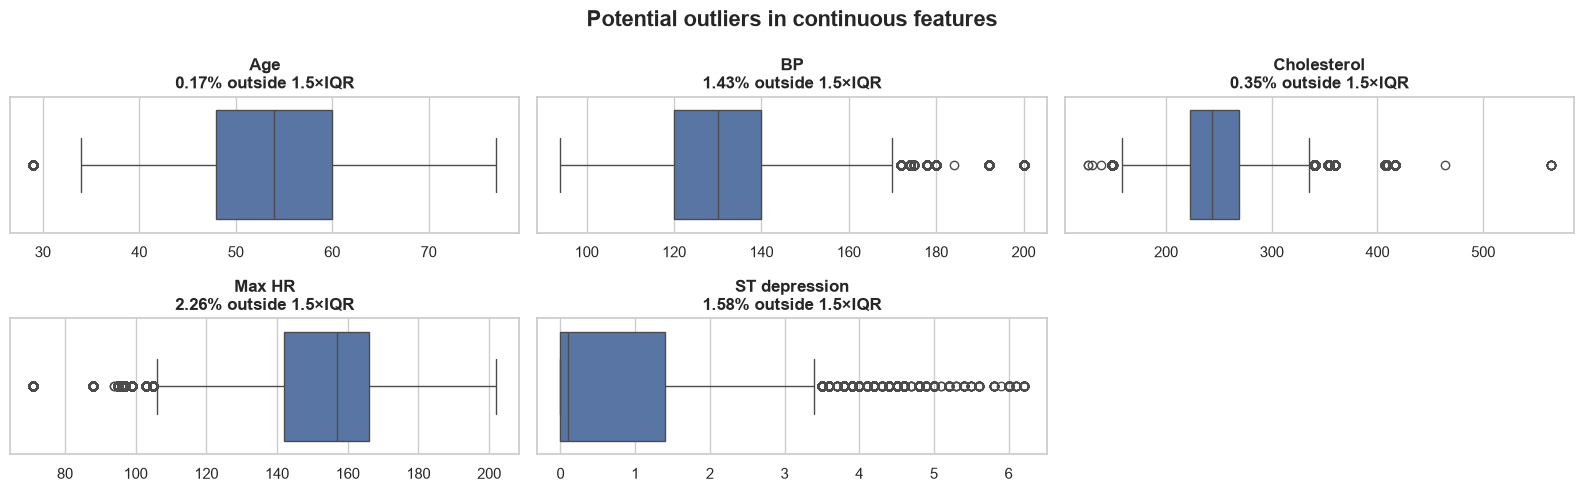

In [74]:
fig, axes = plt.subplots(2, 3, figsize=(16, 5))
axes = axes.ravel()

for ax, col in zip(axes, continuous_features):
    values = train_df[col].dropna()

    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    outlier_share = ((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).mean() * 100

    sns.boxplot(x=values, ax=ax)
    ax.set_title(f'{col}\n{outlier_share:.2f}% outside 1.5×IQR', weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

for ax in axes[len(continuous_features):]:
    ax.remove()

fig.suptitle('Potential outliers in continuous features', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

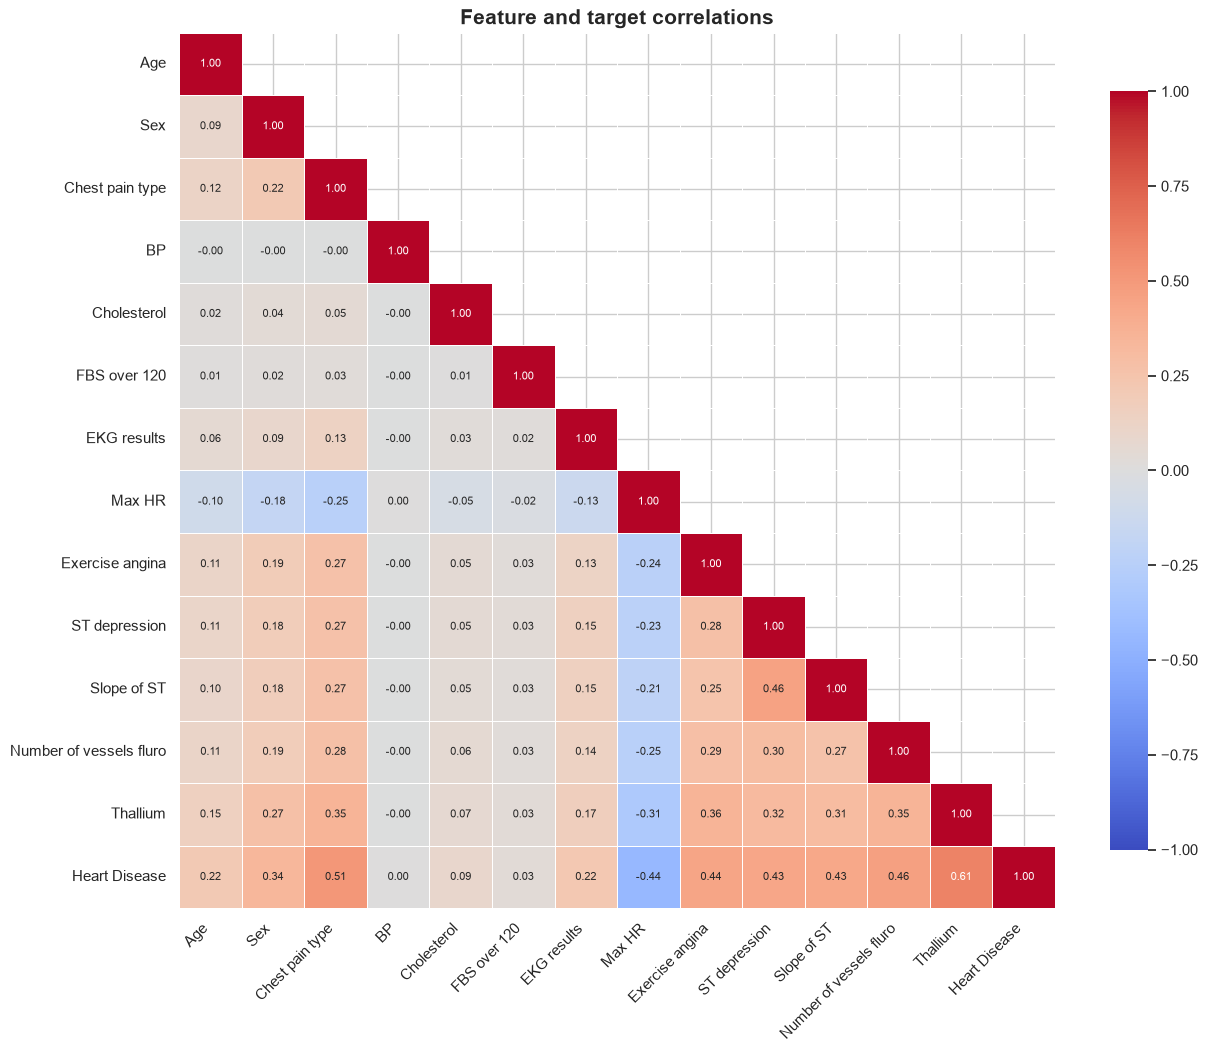

In [83]:
corr = train_df.corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(13, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

plt.title("Feature and target correlations", fontsize=15, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Baseline models

The goal of this section is to create a clean reference point before feature engineering. Both models use only the original competition features, without bins, digit features, or interactions.

In [5]:
BASELINE_RANDOM_STATE = 42
BASELINE_N_SPLITS = 5
BASELINE_OUTPUT_DIR = Path('outputs') / 'baselines'
BASELINE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

baseline_X = train_df.drop(columns=[TARGET]).copy()
baseline_y = train_df[TARGET].astype(int).copy()

baseline_cv = StratifiedKFold(
    n_splits=BASELINE_N_SPLITS,
    shuffle=True,
    random_state=BASELINE_RANDOM_STATE,
)

baseline_oof_predictions = pd.DataFrame(index=train_df.index)
baseline_oof_predictions[TARGET] = baseline_y

baseline_fold_scores = {}
baseline_results = []

In [10]:
def run_sklearn_oof_baseline(model_name, estimator, X, y, cv):
    oof_predictions = np.zeros(len(y), dtype=float)
    fold_scores = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = clone(estimator)

        model.fit(X_train, y_train)

        valid_predictions = model.predict_proba(X_valid)[:, 1]

        oof_predictions[valid_idx] = valid_predictions

        fold_auc = roc_auc_score(y_valid, valid_predictions)
        fold_scores.append(fold_auc)

        print(f'{model_name} fold {fold}: AUC = {fold_auc:.6f}')

    oof_auc = roc_auc_score(y, oof_predictions)

    print(f'{model_name} OOF AUC: {oof_auc:.6f}')

    return oof_predictions, fold_scores, oof_auc


logistic_preprocessor = ColumnTransformer(
    transformers=[
        ('continuous', StandardScaler(), continuous_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

logistic_baseline = Pipeline(
    steps=[
        ('preprocessor', logistic_preprocessor),
        ('model', LogisticRegression(max_iter=1000, solver='lbfgs')),
    ]
)

logistic_oof, logistic_fold_scores, logistic_oof_auc = run_sklearn_oof_baseline(
    model_name='Logistic Regression baseline',
    estimator=logistic_baseline,
    X=baseline_X,
    y=baseline_y,
    cv=baseline_cv,
)

baseline_oof_predictions['logistic_regression'] = logistic_oof

baseline_fold_scores['logistic_regression'] = logistic_fold_scores

baseline_results.append({
    'model': 'Logistic Regression',
    'oof_auc': logistic_oof_auc,
    'mean_fold_auc': np.mean(logistic_fold_scores),
    'std_fold_auc': np.std(logistic_fold_scores),
})

Logistic Regression baseline fold 1: AUC = 0.953237
Logistic Regression baseline fold 2: AUC = 0.952257
Logistic Regression baseline fold 3: AUC = 0.952974
Logistic Regression baseline fold 4: AUC = 0.952591
Logistic Regression baseline fold 5: AUC = 0.953320
Logistic Regression baseline OOF AUC: 0.952874


In [11]:
def run_catboost_oof_baseline(model_name, X, y, cv, cat_features):
    oof_predictions = np.zeros(len(y), dtype=float)
    fold_scores = []
    best_iterations = []

    params = {
        'iterations': 1000,
        'learning_rate': 0.05,
        'depth': 6,
        'l2_leaf_reg': 3.0,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': BASELINE_RANDOM_STATE,
        'allow_writing_files': False,
        'verbose': False,
    }

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        train_pool = Pool(X_train, y_train, cat_features=cat_features)
        valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)

        model = CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=valid_pool,
            early_stopping_rounds=100,
            use_best_model=True,
        )

        valid_predictions = model.predict_proba(valid_pool)[:, 1]
        oof_predictions[valid_idx] = valid_predictions

        fold_auc = roc_auc_score(y_valid, valid_predictions)
        fold_scores.append(fold_auc)
        best_iterations.append(model.get_best_iteration())
        print(
            f'{model_name} fold {fold}: AUC = {fold_auc:.6f}, '
            f'best_iteration = {model.get_best_iteration()}'
        )

    oof_auc = roc_auc_score(y, oof_predictions)

    print(f'{model_name} OOF AUC: {oof_auc:.6f}')

    return oof_predictions, fold_scores, oof_auc, best_iterations


catboost_oof, catboost_fold_scores, catboost_oof_auc = run_catboost_oof_baseline(
    model_name='CatBoost baseline',
    X=baseline_X,
    y=baseline_y,
    cv=baseline_cv,
    cat_features=categorical_features,
)

baseline_oof_predictions['catboost'] = catboost_oof
baseline_fold_scores['catboost'] = catboost_fold_scores
baseline_results.append({
    'model': 'CatBoost',
    'oof_auc': catboost_oof_auc,
    'mean_fold_auc': np.mean(catboost_fold_scores),
    'std_fold_auc': np.std(catboost_fold_scores),
})


CatBoost baseline fold 1: AUC = 0.955770, best_iteration = 988


KeyboardInterrupt: 

In [12]:
baseline_summary = pd.DataFrame(baseline_results).sort_values('oof_auc', ascending=False)

baseline_oof_predictions.to_csv(BASELINE_OUTPUT_DIR / 'oof_predictions.csv')
baseline_summary.to_csv(BASELINE_OUTPUT_DIR / 'baseline_results.csv', index=False)

print('Baseline summary:')
print(baseline_summary.to_string(index=False))
print(f'OOF predictions saved to: {BASELINE_OUTPUT_DIR / "oof_predictions.csv"}')
print(f'Baseline results saved to: {BASELINE_OUTPUT_DIR / "baseline_results.csv"}')


Baseline summary:
              model  oof_auc  mean_fold_auc  std_fold_auc
Logistic Regression 0.952874       0.952876      0.000401
Logistic Regression 0.952874       0.952876      0.000401
OOF predictions saved to: outputs\baselines\oof_predictions.csv
Baseline results saved to: outputs\baselines\baseline_results.csv


In [ ]:
X = pd.read_csv('datasets/train.csv')
cat_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST',
                'Number of vessels fluro', 'Thallium', 'Age_bin', 'BP_bin', 'Cholesterol_bin', 'MaxHR_bin',
                'ST_bin']

# Split continuous features into bins
X['Age_bin'] = pd.cut(X['Age'], bins=5).astype(str)
X['BP_bin'] = pd.cut(X['BP'], bins=5).astype(str)
X['Cholesterol_bin'] = pd.cut(X['Cholesterol'], bins=5).astype(str)
X['MaxHR_bin'] = pd.cut(X['Max HR'], bins=5).astype(str)
X['ST_bin'] = pd.cut(X['ST depression'], bins=5).astype(str)

#Digit
X['Age_units'] = X['Age'] % 10
X['Age_tens'] = (X['Age'] // 10) % 10

X['BP_units'] = X['BP'] % 10
X['BP_tens'] = (X['BP'] // 10) % 10
X['BP_hundreds'] = (X['BP'] // 100) % 10

X['Chol_units'] = X['Cholesterol'] % 10
X['Chol_tens'] = (X['Cholesterol'] // 10) % 10
X['Chol_hundreds'] = (X['Cholesterol'] // 100) % 10

X['MaxHR_units'] = X['Max HR'] % 10
X['MaxHR_tens'] = (X['Max HR'] // 10) % 10
X['MaxHR_hundreds'] = (X['Max HR'] // 100) % 10

X['St_depression_1'] = (X['ST depression'] * 10 % 10).astype(int)

X.replace({'Heart Disease': {'Presence': 1, 'Absence': 0}}, inplace=True)
y = X['Heart Disease'].astype(int)
X.drop(['Heart Disease', 'id'], axis=1, inplace=True)


def objective(trial: optuna.Trial) -> float:
    params = {
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),

        'iterations': 1000,
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': 42,
        'task_type': 'GPU',
        'devices': '0',
        'verbose': False
    }

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_index, test_index in kf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        train_pool = Pool(X_train, y_train, cat_features=cat_features)
        test_pool = Pool(X_test, y_test, cat_features=cat_features)

        model = CatBoostClassifier(**params)

        model.fit(train_pool,
                  eval_set=test_pool,
                  early_stopping_rounds=100)

        preds = model.predict_proba(test_pool)[:, 1]
        score = roc_auc_score(y_test, preds)
        scores.append(score)

    return np.mean(scores)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=500)

print('Number of finished trials: {}'.format(len(study.trials)))

print('Best trial:')
trial = study.best_trial

print('Value: {}'.format(trial.value))

print('Params: ')
for key, value in trial.params.items():
    print('{}: {}'.format(key, value))

# Best result: 0.955525302701582 with parameters {'iterations': 1209, 'depth': 5, 'learning_rate': 0.08375766130052575, 'l2_leaf_reg': 3.9695263497534183}

In [21]:
X = pd.read_csv('test.csv')

#Bin
X['Age_bin'] = pd.cut(X['Age'], bins=5).astype(str)
X['BP_bin'] = pd.cut(X['BP'], bins=5).astype(str)
X['Cholesterol_bin'] = pd.cut(X['Cholesterol'], bins=5).astype(str)
X['MaxHR_bin'] = pd.cut(X['Max HR'], bins=5).astype(str)
X['ST_bin'] = pd.cut(X['ST depression'], bins=5).astype(str)

#Digit
X['Age_units'] = X['Age'] % 10
X['Age_tens'] = (X['Age'] // 10) % 10

X['BP_units'] = X['BP'] % 10
X['BP_tens'] = (X['BP'] // 10) % 10
X['BP_hundreds'] = (X['BP'] // 100) % 10

X['Chol_units'] = X['Cholesterol'] % 10
X['Chol_tens'] = (X['Cholesterol'] // 10) % 10
X['Chol_hundreds'] = (X['Cholesterol'] // 100) % 10

X['MaxHR_units'] = X['Max HR'] % 10
X['MaxHR_tens'] = (X['Max HR'] // 10) % 10
X['MaxHR_hundreds'] = (X['Max HR'] // 100) % 10

id = X['id']
X.drop('id', axis=1, inplace=True)
preds = model.predict_proba(X)[:, 1]

sample_submission = pd.DataFrame(data={'id': id, 'Heart Disease': preds})
sample_submission.to_csv('sample_submission.csv', index=False)